# nb30 — CCCP prior on $1{-}b$: CNC vs PS vs combined (full-sky, B=1.35 CNC sel.)

Yang26-rotated **full-sky** tSZ map + B=1.35 CNC selection mock (z ≤ 1, 10 bins):

| Run | Chain |
|-----|-------|
| CNC only | `chains/cnc_cosmo_arnaudB135_Y500c_cccp/cnc_cosmo` |
| tSZ PS only | `chains/yy_fullsky_arnaudB135_Y500c_cccp/yy` |
| CNC + full-sky PS | `chains/cnc_yy_combined_fullsky_arnaudB135_Y500c_cccp/combined` |

**Sampled:** `omega_cdm`, `sigma8`, `h`, `n_s`, **`one_minus_b ~ N(0.780,0.092)`** (CCCP), `alpha_SZ ~ N(1,0.1)`, `sigma_lnY ~ N(0.173,0.023)`

**Derived:** `B = 1/(1-b)`

**Fixed:** `A_SZ`, `omega_b` (D3A), `tau_reio`, `m_nu` (CNC/combined only)

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from getdist import loadMCSamples, plots

REPO = "/scratch/scratch-lxu/flamingo_repo"
OUTDIR = os.path.join(REPO, "figures", "nb30_fullsky_cccp_contours")
os.makedirs(OUTDIR, exist_ok=True)

N_QGT5 = 768
OM_TRUTH, S8_TRUTH = 0.306, 0.808
A_SZ_FIXED = -4.28739604
LOAD_SETTINGS = {"ignore_rows": 0.1}
R1_TARGET = 0.05

RUNS = [
    dict(
        tag="cnc",
        path=os.path.join(REPO, "chains", "cnc_cosmo_arnaudB135_Y500c_cccp", "cnc_cosmo"),
        label="CNC only",
        color="#d62728",
        run_hint="bash cobaya/run_cnc_cosmo_B135_cccp.sh",
    ),
    dict(
        tag="yy",
        path=os.path.join(REPO, "chains", "yy_fullsky_arnaudB135_Y500c_cccp", "yy"),
        label="tSZ PS only",
        color="#2ca02c",
        run_hint="bash cobaya/run_yy_fullsky_B135_cccp.sh",
    ),
    dict(
        tag="comb",
        path=os.path.join(REPO, "chains", "cnc_yy_combined_fullsky_arnaudB135_Y500c_cccp", "combined"),
        label="CNC + full-sky PS",
        color="#8c564b",
        run_hint="bash cobaya/run_cnc_yy_combined_fullsky_B135_cccp.sh",
    ),
]

TRUTH = {
    "Omega_m": OM_TRUTH, "sigma8": S8_TRUTH,
    "S8": S8_TRUTH * np.sqrt(OM_TRUTH / 0.3),
    "F": S8_TRUTH * (OM_TRUTH / 1.35) ** 0.40 * 0.681 ** (-0.21),
    "h": 0.681, "omega_b": 0.022539, "n_s": 0.967,
    "alpha_SZ": 1.12, "sigma_lnY": 0.173, "B": 1.35, "one_minus_b": 0.780,
}
CHAIN_PARS = ["Omega_m", "sigma8", "h", "n_s", "alpha_SZ", "B", "sigma_lnY"]
DERIVED_PARS = ["S8", "F"]
COSMO_PARS = ["Omega_m", "sigma8", "S8", "F"]
PARS_PRINT = CHAIN_PARS[:2] + DERIVED_PARS + CHAIN_PARS[2:]
FIXED_PARS = {"A_SZ": A_SZ_FIXED, "omega_b": 0.022539}


def _add_derived(sample):
    p = sample.getParams()
    sample.addDerived(
        p.sigma8 * np.sqrt(p.Omega_m / 0.3), name="S8", label=r"S_8",
    )
    h = getattr(p, "h", 0.681)  # CCCP mean when h fixed in chain
    sample.addDerived(
        p.sigma8 * (p.Omega_m / p.B) ** 0.40 * h ** (-0.21), name="F", label=r"F",
    )
    return sample


def _load_chain(path, label, run_hint):
    if not os.path.exists(path + ".1.txt"):
        print(f"MISSING: {path}")
        print(f"  run: {run_hint}")
        return None
    sample = loadMCSamples(path, settings=LOAD_SETTINGS)
    sample = _add_derived(sample)
    r1 = getattr(sample, "Rminus1", None)
    print(f"\n{label}: {sample.numrows} post-discard samples", end="")
    if r1 is not None:
        flag = " (converged)" if r1 <= R1_TARGET else " (running)"
        print(f"; R-1={r1:.3f}{flag}", end="")
    print()
    names = set(sample.getParamNames().list())
    print(f"{label} — full-sky B135 mock (N={N_QGT5}):")
    for nm in PARS_PRINT:
        if nm in names:
            print(f"  {nm:12s} = {sample.mean(nm):.4f} +/- {sample.std(nm):.4f}")
    for nm, val in FIXED_PARS.items():
        print(f"  {nm:12s} = {val:.6f} (fixed)")
    return sample


loaded = {}
for run in RUNS:
    s = _load_chain(run["path"], run["label"], run["run_hint"])
    if s is not None:
        loaded[run["tag"]] = s

if len(loaded) >= 2:
    for tag_a, tag_b, key in [("cnc", "comb", "S8"), ("yy", "comb", "S8"), ("cnc", "comb", "B")]:
        if tag_a in loaded and tag_b in loaded:
            la = next(r["label"] for r in RUNS if r["tag"] == tag_a)
            lb = next(r["label"] for r in RUNS if r["tag"] == tag_b)
            print(f"Δ{key} ({lb} − {la}) = {loaded[tag_b].mean(key) - loaded[tag_a].mean(key):+.4f}")

chains = [loaded[r["tag"]] for r in RUNS if r["tag"] in loaded]
labels = [r["label"] for r in RUNS if r["tag"] in loaded]
colors = [r["color"] for r in RUNS if r["tag"] in loaded]

if len(chains) < 2:
    print("\nNeed at least two chains for contour plots.")
else:
    names = [set(s.getParamNames().list()) for s in chains]
    full_pars = CHAIN_PARS[:2] + DERIVED_PARS + CHAIN_PARS[2:]
    plot_pars = [p for p in full_pars if all(p in n for n in names)]
    cosmo_pars = [p for p in COSMO_PARS if all(p in n for n in names)]


CNC only: 4176 post-discard samples
CNC only — full-sky B135 mock (N=768):
  Omega_m      = 0.3013 +/- 0.0156
  sigma8       = 0.7442 +/- 0.0260
  S8           = 0.7455 +/- 0.0317
  F            = 0.4479 +/- 0.0035
  h            = 0.6805 +/- 0.0220
  n_s          = 0.9683 +/- 0.0135
  alpha_SZ     = 1.0988 +/- 0.0382
  B            = 1.3175 +/- 0.1548
  sigma_lnY    = 0.1756 +/- 0.0239
  A_SZ         = -4.287396 (fixed)
  omega_b      = 0.022539 (fixed)

tSZ PS only: 9396 post-discard samples
tSZ PS only — full-sky B135 mock (N=768):
  Omega_m      = 0.3544 +/- 0.0649
  sigma8       = 0.8118 +/- 0.0523
  S8           = 0.8747 +/- 0.0568
  F            = 0.5208 +/- 0.0057
  h            = 0.6827 +/- 0.0235
  n_s          = 0.9682 +/- 0.0142
  alpha_SZ     = 1.1040 +/- 0.0457
  B            = 1.2926 +/- 0.1463
  sigma_lnY    = 0.1726 +/- 0.0232
  A_SZ         = -4.287396 (fixed)
  omega_b      = 0.022539 (fixed)

CNC + full-sky PS: 3492 post-discard samples
CNC + full-sky PS — full-sky

## Triangle: cosmology + S8, F + nuisances (CCCP $1{-}b$ prior)

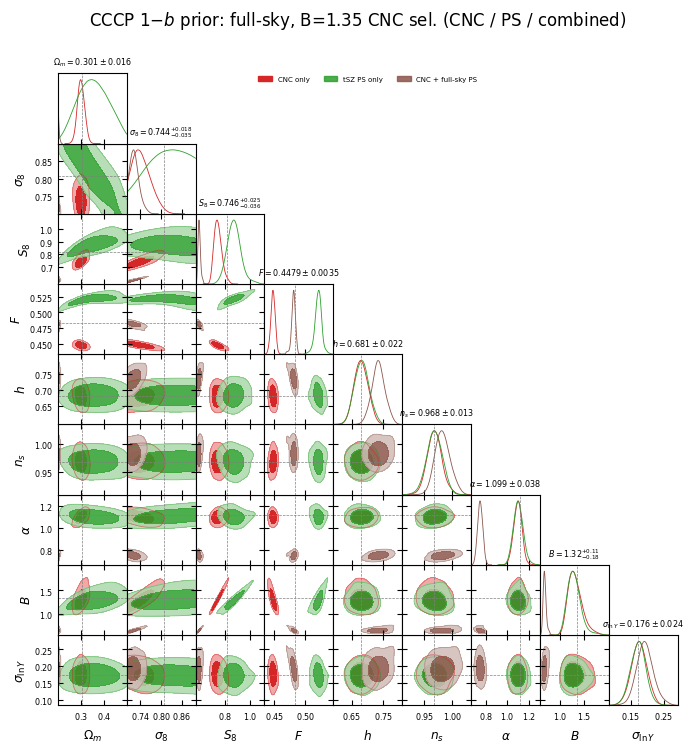

In [2]:
if len(chains) >= 2 and plot_pars:
    g = plots.get_subplot_plotter(width_inch=8)
    g.settings.legend_fontsize = 10
    g.settings.figure_legend_frame = False
    g.triangle_plot(
        chains, plot_pars, filled=True, contour_colors=colors,
        legend_labels=labels, legend_loc="upper center", legend_ncol=3,
        title_limit=1, markers={k: TRUTH[k] for k in plot_pars if k in TRUTH},
    )
    g.fig.suptitle(
        r"CCCP $1{-}b$ prior: full-sky, B=1.35 CNC sel. (CNC / PS / combined)",
        fontsize=12,
    )
    g.fig.subplots_adjust(top=0.90)
    g.export(os.path.join(OUTDIR, "fullsky_cccp_triangle.pdf"))
    g.export(os.path.join(OUTDIR, "fullsky_cccp_triangle.png"))
    plt.show()
else:
    print("Triangle skipped.")

## Ω_m–σ_8 plane

saved -> /scratch/scratch-lxu/flamingo_repo/figures/nb30_fullsky_cccp_contours


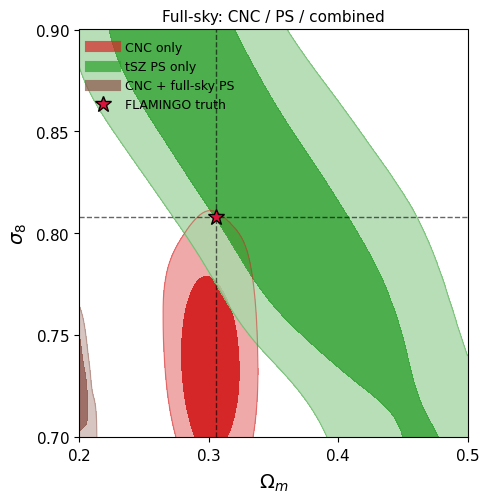

In [3]:
from matplotlib.lines import Line2D

if len(chains) >= 2:
    g2 = plots.get_subplot_plotter(width_inch=5)
    g2.plot_2d(chains, "Omega_m", "sigma8", filled=True, colors=colors)
    ax = plt.gca()
    ax.plot(OM_TRUTH, S8_TRUTH, "*", color="crimson", ms=12, mec="k", zorder=10)
    ax.axvline(OM_TRUTH, color="k", ls="--", lw=1, alpha=0.6)
    ax.axhline(S8_TRUTH, color="k", ls="--", lw=1, alpha=0.6)
    handles = [
        Line2D([], [], color=c, lw=8, alpha=0.7, label=l)
        for c, l in zip(colors, labels)
    ] + [
        Line2D([], [], color="crimson", marker="*", ls="", ms=12, mec="k", label="FLAMINGO truth"),
    ]
    ax.legend(handles=handles, fontsize=9, loc="upper left", frameon=False)
    ax.set_title(r"Full-sky: CNC / PS / combined", fontsize=11)
    g2.export(os.path.join(OUTDIR, "fullsky_cccp_Om_s8_plane.pdf"))
    g2.export(os.path.join(OUTDIR, "fullsky_cccp_Om_s8_plane.png"))
    print("saved ->", OUTDIR)
    plt.show()
else:
    print("Ωm–σ8 plane skipped.")

---

## CCCP + fixed $h$, $n_s$, $\alpha_{\rm SZ}$

Same CCCP setup but **`h=0.681`, `n_s=0.967`, `alpha_SZ=1.12` fixed**; other priors unchanged.


In [4]:
FIXALPHA_RUNS = [
    dict(tag="cnc", path=os.path.join(REPO, "chains", "cnc_cosmo_arnaudB135_Y500c_cccp_fixAlpha112", "cnc_cosmo"),
         label="CNC only (fix α)", color="#d62728",
         run_hint="bash cobaya/run_cnc_cosmo_B135_cccp_fixAlpha112.sh"),
    dict(tag="yy", path=os.path.join(REPO, "chains", "yy_fullsky_arnaudB135_Y500c_cccp_fixAlpha112", "yy"),
         label="tSZ PS only (fix α)", color="#2ca02c",
         run_hint="bash cobaya/run_yy_fullsky_B135_cccp_fixAlpha112.sh"),
    dict(tag="comb", path=os.path.join(REPO, "chains", "cnc_yy_combined_fullsky_arnaudB135_Y500c_cccp_fixAlpha112", "combined"),
         label="CNC + full-sky PS (fix α)", color="#8c564b",
         run_hint="bash cobaya/run_cnc_yy_combined_fullsky_B135_cccp_fixAlpha112.sh"),
]

fixalpha_loaded = {}
for run in FIXALPHA_RUNS:
    s = _load_chain(run["path"], run["label"], run["run_hint"])
    if s is not None:
        fixalpha_loaded[run["tag"]] = s

if "cnc" in fixalpha_loaded and "comb" in fixalpha_loaded:
    print(f"\n[fix α] ΔS8 (comb − CNC) = {fixalpha_loaded['comb'].mean('S8') - fixalpha_loaded['cnc'].mean('S8'):+.4f}")
    print(f"[fix α] ΔB  (comb − CNC) = {fixalpha_loaded['comb'].mean('B') - fixalpha_loaded['cnc'].mean('B'):+.4f}")

fixalpha_chains = [fixalpha_loaded[r["tag"]] for r in FIXALPHA_RUNS if r["tag"] in fixalpha_loaded]
fixalpha_labels = [r["label"] for r in FIXALPHA_RUNS if r["tag"] in fixalpha_loaded]
fixalpha_colors = [r["color"] for r in FIXALPHA_RUNS if r["tag"] in fixalpha_loaded]

FIXALPHA_OUTDIR = os.path.join(REPO, "figures", "nb30_fullsky_cccp_fixAlpha112_contours")
os.makedirs(FIXALPHA_OUTDIR, exist_ok=True)
fixalpha_plot_pars = [p for p in plot_pars if p not in ("alpha_SZ", "h", "n_s")]


/scratch/scratch-lxu/flamingo_repo/chains/cnc_cosmo_arnaudB135_Y500c_cccp_fixAlpha112/cnc_cosmo.1.txt
Removed 0.1 as burn in

CNC only (fix α): 2340 post-discard samples
CNC only (fix α) — full-sky B135 mock (N=768):
  Omega_m      = 0.3048 +/- 0.0130
  sigma8       = 0.7386 +/- 0.0227
  S8           = 0.7444 +/- 0.0305
  F            = 0.4480 +/- 0.0034
  B            = 1.3072 +/- 0.1479
  sigma_lnY    = 0.1767 +/- 0.0242
  A_SZ         = -4.287396 (fixed)
  omega_b      = 0.022539 (fixed)

tSZ PS only (fix α): 3366 post-discard samples
tSZ PS only (fix α) — full-sky B135 mock (N=768):
  Omega_m      = 0.3476 +/- 0.0610
  sigma8       = 0.8200 +/- 0.0515
  S8           = 0.8756 +/- 0.0506
  F            = 0.5213 +/- 0.0048
  B            = 1.3000 +/- 0.1324
  sigma_lnY    = 0.1724 +/- 0.0239
  A_SZ         = -4.287396 (fixed)
  omega_b      = 0.022539 (fixed)


/scratch/scratch-lxu/flamingo_repo/chains/cnc_yy_combined_fullsky_arnaudB135_Y500c_cccp_fixAlpha112/combined.1.txt
Removed 0.1 as burn in

CNC + full-sky PS (fix α): 2934 post-discard samples
CNC + full-sky PS (fix α) — full-sky B135 mock (N=768):
  Omega_m      = 0.2338 +/- 0.0068
  sigma8       = 0.7016 +/- 0.0018
  S8           = 0.6193 +/- 0.0090
  F            = 0.4811 +/- 0.0020
  B            = 0.7349 +/- 0.0254
  sigma_lnY    = 0.1614 +/- 0.0231
  A_SZ         = -4.287396 (fixed)
  omega_b      = 0.022539 (fixed)

[fix α] ΔS8 (comb − CNC) = -0.1251
[fix α] ΔB  (comb − CNC) = -0.5722


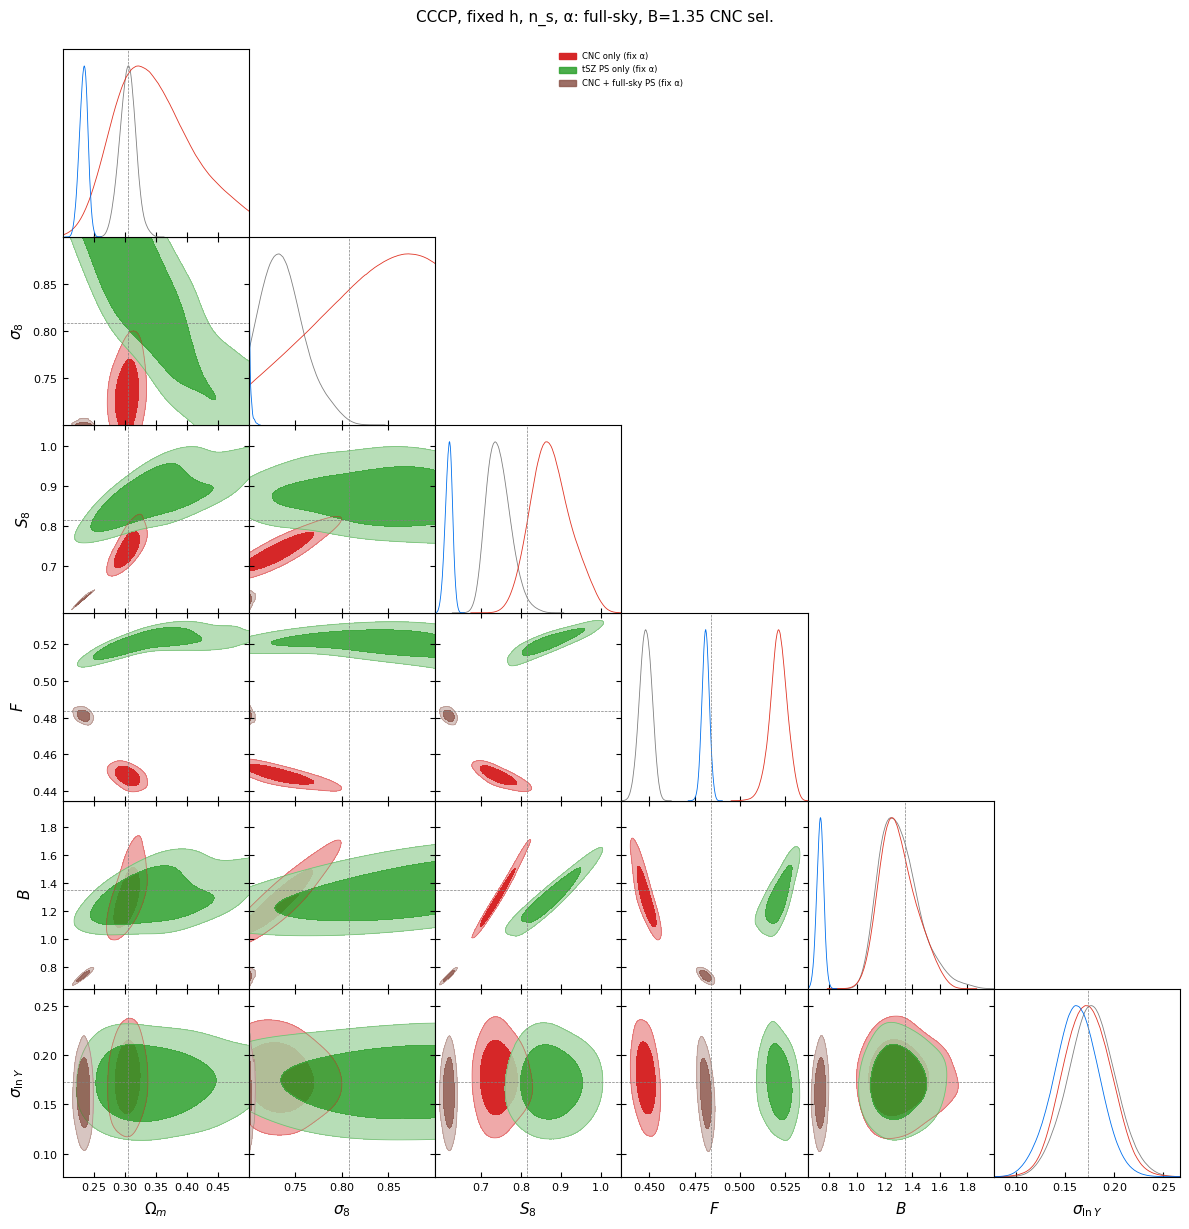

saved -> /scratch/scratch-lxu/flamingo_repo/figures/nb30_fullsky_cccp_fixAlpha112_contours


In [5]:
if len(fixalpha_chains) >= 2:
    g_fa = plots.getSubplotPlotter()
    g_fa.settings.legend_fontsize = 9
    g_fa.settings.figure_legend_frame = False
    g_fa.triangle_plot(
        fixalpha_chains, params=fixalpha_plot_pars, legend_labels=fixalpha_labels,
        colors=fixalpha_colors, filled=True,
        legend_loc="upper center", legend_ncol=1,
        markers={k: TRUTH[k] for k in fixalpha_plot_pars if k in TRUTH},
        marker_color="k", marker_style="*", marker_size=80,
    )
    g_fa.fig.suptitle(r"CCCP, fixed h, n_s, α: full-sky, B=1.35 CNC sel.", fontsize=11, y=1.02)
    g_fa.export(os.path.join(FIXALPHA_OUTDIR, "fullsky_cccp_fixAlpha112_triangle.pdf"))
    g_fa.export(os.path.join(FIXALPHA_OUTDIR, "fullsky_cccp_fixAlpha112_triangle.png"))
    plt.show()
    print("saved ->", FIXALPHA_OUTDIR)
else:
    print("fixAlpha chains not ready yet.")
